# Spectral denoising with a 1D DDPM

This tutorial applies the conditional denoising interface to one-dimensional spectra (PLAN.md item D1), the 1D counterpart of `ddpm_denoising.ipynb`'s image restoration. It trains `DenoisingDDPM` (`model_cls=UNet1DModel`) on real SDSS spectra from [UniverseTBD/mmu_sdss_sdss](https://huggingface.co/datasets/UniverseTBD/mmu_sdss_sdss) (the Multimodal Universe collection's SDSS partition), corrupted with additive Gaussian noise. D1's own reference, [spectrai](https://github.com/conor-horgan/spectrai), expects a pre-made noisy/clean pair rather than defining a corruption recipe itself, and reports only PSNR for its `Denoising` task (`trainer.py`'s per-task metrics track PSNR/SSIM only for `Super-Resolution`), and this notebook follows both: plain additive noise, PSNR-only evaluation, no SSIM.

## What you will do

1. Load and normalize real SDSS spectra, then inject noise.
2. Train a 1D conditional DDPM and restore held-out spectra.
3. Compare restoration quality against the noisy input with PSNR.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from diffusers import UNet1DModel
from huggingface_hub import HfApi, hf_hub_download
from torch.nn import functional
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().parent))
from astrogen.tasks import DenoisingDDPM
from examples.evaluation.metrics import psnr
from examples.evaluation.splits import train_val_split

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
REPO_ID = "UniverseTBD/mmu_sdss_sdss"
SPECTRUM_LENGTH = 256
torch.manual_seed(0)
print(f"Using {DEVICE}")

Could not find the bitsandbytes CUDA binary at PosixPath('/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/bitsandbytes/libbitsandbytes_cuda128.so')


The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.


Using cuda


## Load and normalize real spectra

Each SDSS spectrum's flux array (a fixed-length, per-spectrograph grid) has bad pixels flagged by its own `mask`; those are linearly filled in before a per-spectrum robust `asinh` stretch (median/MAD baseline, following the same recipe as `examples/cgdpm_super_resolution.ipynb`'s image normalization) maps it into `[-1, 1]`. Spectra are then resampled onto a common `SPECTRUM_LENGTH` grid.

mmu_sdss_sdss/dataset/Norder=4/Dir=0/Npi(…):   0%|          | 0.00/32.2M [00:00<?, ?B/s]

mmu_sdss_sdss/dataset/Norder=4/Dir=0/Npi(…):   0%|          | 0.00/52.0M [00:00<?, ?B/s]

mmu_sdss_sdss/dataset/Norder=4/Dir=0/Npi(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

mmu_sdss_sdss/dataset/Norder=4/Dir=0/Npi(…):   0%|          | 0.00/23.4M [00:00<?, ?B/s]

mmu_sdss_sdss/dataset/Norder=4/Dir=0/Npi(…):   0%|          | 0.00/31.3M [00:00<?, ?B/s]

...

mmu_sdss_sdss/dataset/Norder=4/Dir=0/Npi(…):   0%|          | 0.00/28.1M [00:00<?, ?B/s]

mmu_sdss_sdss/dataset/Norder=4/Dir=0/Npi(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

mmu_sdss_sdss/dataset/Norder=4/Dir=0/Npi(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

mmu_sdss_sdss/dataset/Norder=4/Dir=0/Npi(…):   0%|          | 0.00/174M [00:00<?, ?B/s]

mmu_sdss_sdss/dataset/Norder=4/Dir=0/Npi(…):   0%|          | 0.00/26.1M [00:00<?, ?B/s]

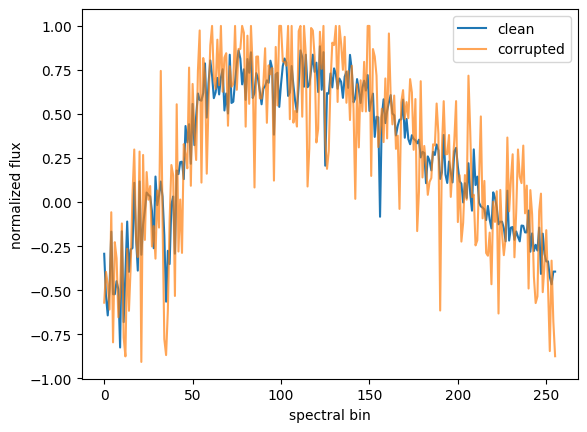

In [2]:
def _load_partitions(count: int, offset: int) -> pd.DataFrame:
    files = sorted(
        f for f in HfApi().list_repo_files(REPO_ID, repo_type="dataset")
        if f.startswith("mmu_sdss_sdss/dataset/Norder=4/")
    )
    frames = []
    for name in files[offset : offset + count]:
        path = hf_hub_download(REPO_ID, name, repo_type="dataset")
        frames.append(pd.read_parquet(path, columns=["spectrum"]))
    return pd.concat(frames, ignore_index=True)

def _normalize(spectrum: dict) -> torch.Tensor | None:
    """Fill bad pixels, robust-`asinh`-stretch into [-1, 1], and resample onto
    the common ``SPECTRUM_LENGTH`` grid (raw flux arrays vary in length across
    spectrograph configurations, so this must happen per-spectrum before any
    batch stacking)."""
    flux = np.asarray(spectrum["flux"], dtype=np.float64)
    wavelength = np.asarray(spectrum["lambda"], dtype=np.float64)
    valid = ~np.asarray(spectrum["mask"], dtype=bool) & (wavelength > 0) & np.isfinite(flux)
    if valid.sum() < 10:
        return None
    index = np.arange(len(flux))
    flux[~valid] = np.interp(index[~valid], index[valid], flux[valid])
    median = np.median(flux[valid])
    noise = np.median(np.abs(flux[valid] - median)) * 1.4826 or 1.0
    compressed = np.arcsinh((flux - median) / noise)
    low, high = compressed.min(), compressed.max()
    normalized = (compressed - low) / (high - low + 1e-8) * 2 - 1
    tensor = torch.from_numpy(normalized.astype(np.float32)).view(1, 1, -1)
    return functional.interpolate(tensor, size=SPECTRUM_LENGTH, mode="linear", align_corners=False).view(-1)

def load_spectra(count: int, offset: int) -> torch.Tensor:
    frame = _load_partitions(count, offset)
    spectra = [_normalize(s) for s in frame["spectrum"]]
    return torch.stack([s for s in spectra if s is not None]).unsqueeze(1)

def corrupt(clean: torch.Tensor) -> torch.Tensor:
    noise_sigma = torch.empty(clean.shape[0], 1, 1).uniform_(0.05, 0.3)
    return (clean + noise_sigma * torch.randn_like(clean)).clamp(-1, 1)

# Disjoint partition ranges for train/val, so no spectrum appears in both.
train_clean = load_spectra(count=25, offset=0)
val_clean = load_spectra(count=6, offset=25)
train_corrupted, val_corrupted = corrupt(train_clean), corrupt(val_clean)

plt.plot(val_clean[0, 0], label="clean")
plt.plot(val_corrupted[0, 0], label="corrupted", alpha=0.7)
plt.legend()
plt.xlabel("spectral bin")
plt.ylabel("normalized flux")
plt.show()

## Train the 1D conditional DDPM

Passing `model_cls=UNet1DModel` selects the 1D U-Net configuration. `DenoisingDDPM` otherwise uses the same conditioning interface as the image denoiser, matched here to the same training scale (1000 timesteps, 100 epochs) used by the other real-data DDPM notebooks in this repo.

DenoisingDDPM:   0%|          | 0/100 [00:00<?, ?it/s]

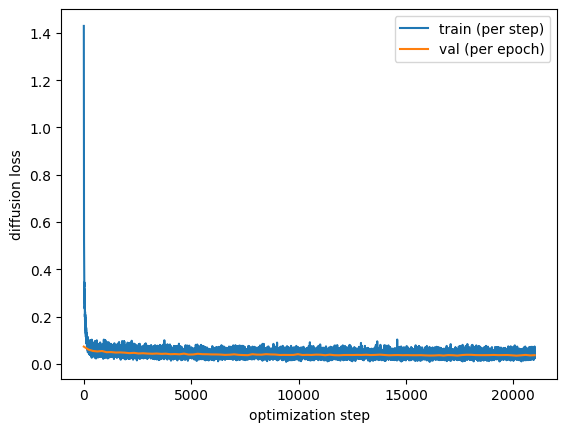

In [3]:
model = DenoisingDDPM(base_channels=32, timesteps=1_000, model_cls=UNet1DModel).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
loader = DataLoader(TensorDataset(train_corrupted, train_clean), batch_size=128, shuffle=True)
train_losses, val_losses = [], []

progress = tqdm(range(100), desc="DenoisingDDPM")
for _ in progress:
    model.train()
    for batch_corrupted, batch_clean in loader:
        optimizer.zero_grad()
        loss = model(batch_corrupted.to(DEVICE), batch_clean.to(DEVICE))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        val_loss = model(val_corrupted.to(DEVICE), val_clean.to(DEVICE)).item()
    val_losses.append(val_loss)
    progress.set_postfix(train_loss=f"{train_losses[-1]:.4f}", val_loss=f"{val_loss:.4f}")

plt.plot(train_losses, label="train (per step)")
plt.plot(
    torch.linspace(0, len(train_losses) - 1, len(val_losses)), val_losses, label="val (per epoch)"
)
plt.xlabel("optimization step")
plt.ylabel("diffusion loss")
plt.legend()
plt.show()

## Evaluate signal fidelity

PSNR measures error relative to the clean target: higher is better. Comparing against the noisy input checks whether denoising improves on simply returning the observation.

DDPM PSNR (11095 val samples): 23.16 dB
noisy-input PSNR: 20.71 dB


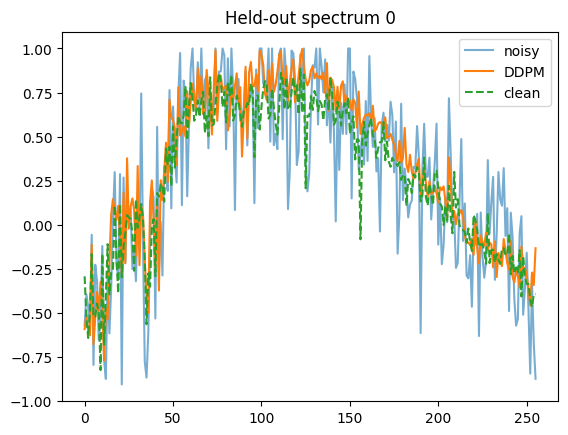

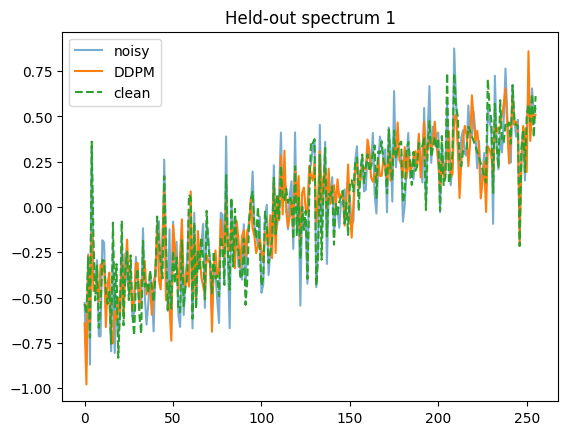

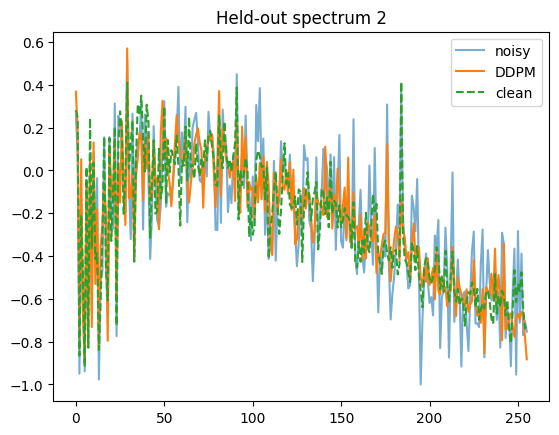

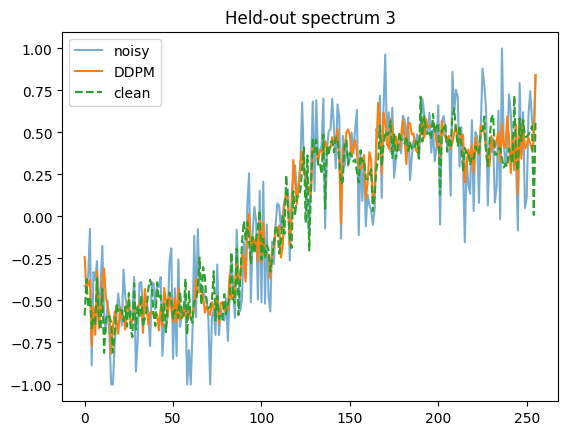

In [4]:
model.eval()
VISUALIZE_COUNT = 4
holdout_clean = val_clean.to(DEVICE)
holdout_corrupted = val_corrupted.to(DEVICE)
with torch.no_grad():
    denoised = model.sample(holdout_corrupted)

print(f"DDPM PSNR ({len(holdout_clean)} val samples): {psnr(denoised, holdout_clean):.2f} dB")
print(f"noisy-input PSNR: {psnr(holdout_corrupted, holdout_clean):.2f} dB")

for index in range(VISUALIZE_COUNT):
    plt.plot(holdout_corrupted[index, 0].cpu(), alpha=0.6, label="noisy")
    plt.plot(denoised[index, 0].cpu(), label="DDPM")
    plt.plot(holdout_clean[index, 0].cpu(), linestyle="--", label="clean")
    plt.title(f"Held-out spectrum {index}")
    plt.legend()
    plt.show()